# Credit Card Default Prediction

## 1. Project Overview

This project develops a machine learning classification model to predict whether a credit card customer will default on their payment in the following month.

The project will use customer demographic information, credit limits, repayment history, bill amounts, and previous payment information to identify patterns associated with default risk.

The goal is to build and evaluate predictive models while considering the business impact of correctly and incorrectly identifying customers at risk of default.

In [1]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [2]:
# import tool

import pandas as pd

In [3]:
# load dataset

df = pd.read_excel(
    "../data/default of credit card clients.xls",
    header=1
)

In [4]:
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.tail(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [6]:
df.shape

(30000, 25)

In [7]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

## 2. Data Understanding

The dataset contains 30,000 credit card customers and 25 columns.

The target variable is `default payment next month`, where:

- 0 = No default
- 1 = Default

The predictor variables include customer demographics, credit limits, repayment history, bill amounts, and previous payment amounts.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [9]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [10]:
df["default payment next month"].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [11]:
# Understand class imbalance
# calculating the percentages rather than looking only at counts.

target_counts = df["default payment next month"].value_counts()

target_percentages = (
    df["default payment next month"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_counts)
print()
print(target_percentages)

default payment next month
0    23364
1     6636
Name: count, dtype: int64

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


### Target Distribution

The target variable is moderately imbalanced:

- No default (0): 23,364 customers — 77.88%
- Default (1): 6,636 customers — 22.12%

Because the majority of customers did not default, model performance should not be evaluated using accuracy alone. Metrics such as precision, recall, F1-score, confusion matrix and ROC-AUC will also be considered.

## 3. Data Quality & Exploratory Analysis

Before building the machine learning models, the dataset was examined for duplicate records, unusual category values, inconsistent encodings, and potentially problematic observations.

In [12]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [13]:
# check whether the customer IDs themselves are unique

df["ID"].nunique()

30000

In [14]:
# Inspect the categorical codes
# Some columns contain numbers, but those numbers actually represent categories, not continuous numerical measurements.

categorical_columns = ["SEX", "EDUCATION", "MARRIAGE"]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [15]:
# Inspect repayment-status codes

payment_status_columns = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

for column in payment_status_columns:
    print(f"\n{column}")
    print(df[column].value_counts().sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

In [16]:
# Create a cleaned copy
# Preserving the original DataFrame and making the transformations in another one

df_clean = df.copy()

In [17]:
# Then cleaning the two categorical variables

# Consolidate undocumented/rare education codes into "Other"
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Consolidate undocumented marriage code into "Other"
df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({
    0: 3
})

In [18]:
print(df_clean["EDUCATION"].value_counts().sort_index())
print()
print(df_clean["MARRIAGE"].value_counts().sort_index())

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [19]:
df_clean["ID"].nunique()

30000

### Data Quality Findings

- No exact duplicate records were identified.
- The dataset contains no missing values.
- Rare or undocumented `EDUCATION` codes (0, 5 and 6) were consolidated into the `Other` category (4).
- The undocumented `MARRIAGE` code 0 was consolidated into the `Other` category (3).
- Repayment-status variables contain special negative codes and were retained for further analysis rather than treated as invalid numerical values.
- `ID` is an identifier and will not be used as a predictive feature.

## 4. Explore Default Behaviour

Exploratory analysis was conducted to identify variables associated with
customer default, beginning with recent repayment behaviour.

In [20]:
# Rename the target: default payment next month

df_clean = df_clean.rename(
    columns={"default payment next month": "DEFAULT"}
)

In [21]:
df_clean.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

In [22]:
# Compare default rate by most recent repayment status
# PAY_0 represents the most recent repayment-status variable in this dataset

default_by_pay0 = (
    df_clean
    .groupby("PAY_0")["DEFAULT"]
    .agg(["count", "sum", "mean"])
)

default_by_pay0["default_rate_pct"] = (
    default_by_pay0["mean"] * 100
).round(2)

default_by_pay0

,count,sum,mean,default_rate_pct
PAY_0,,,,
-2,2759,365,0.132294,13.23
-1,5686,954,0.167781,16.78
0,14737,1888,0.128113,12.81
1,3688,1252,0.339479,33.95
2,2667,1844,0.691414,69.14
3,322,244,0.757764,75.78
4,76,52,0.684211,68.42
5,26,13,0.500000,50.00
6,11,6,0.545455,54.55


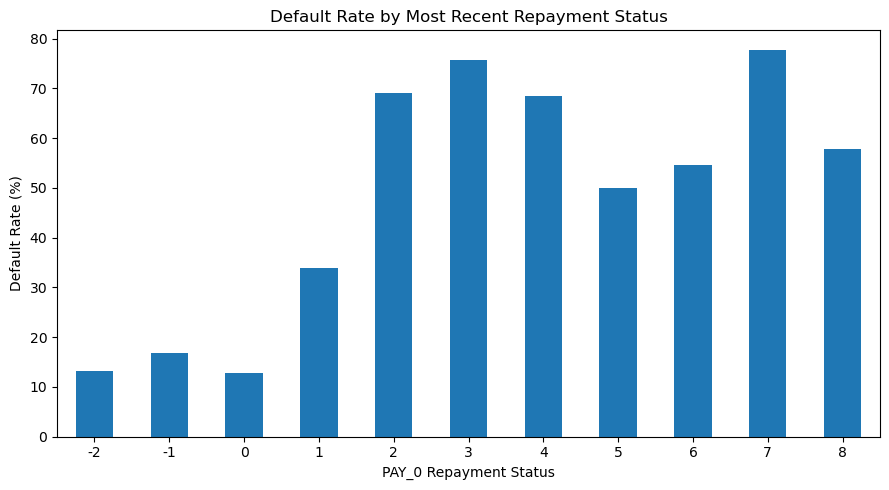

In [23]:
# Visualise it

import matplotlib.pyplot as plt

default_by_pay0["default_rate_pct"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0 Repayment Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
# Credit limit and default
# Investigate whether customers who default have different credit limits.

credit_limit_default = (
    df_clean
    .groupby("DEFAULT")["LIMIT_BAL"]
    .agg(["count", "mean", "median"])
    .round(2)
)

credit_limit_default

,count,mean,median
DEFAULT,,,
0,23364,178099.73,150000.0
1,6636,130109.66,90000.0


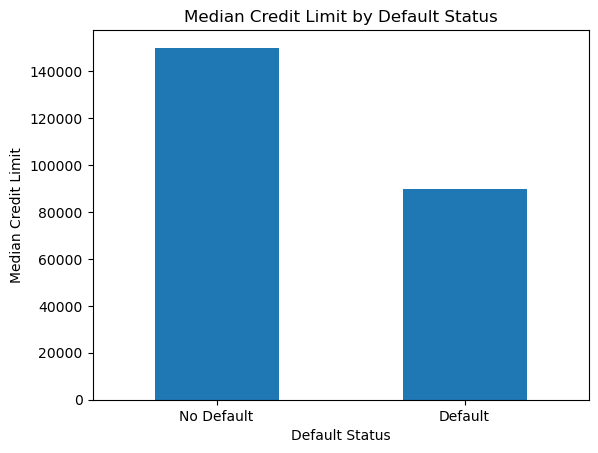

In [25]:
# Visualise credit limit vs default

import matplotlib.pyplot as plt

credit_limit_plot = (
    df_clean
    .groupby("DEFAULT")["LIMIT_BAL"]
    .median()
)

credit_limit_plot.plot(kind="bar")

plt.title("Median Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Median Credit Limit")
plt.xticks(
    ticks=[0, 1],
    labels=["No Default", "Default"],
    rotation=0
)
plt.show()

In [26]:
# Explore default rates by age
# Investigate whether default rates differ across age groups. 
# Instead of comparing individual ages, group customers into age bands to make the results easier to interpret.

# Create age groups
df_clean["AGE_GROUP"] = pd.cut(
    df_clean["AGE"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["21–30", "31–40", "41–50", "51–60", "61+"],
    include_lowest=True
)

# Calculate default rate for each age group
default_by_age = (
    df_clean
    .groupby("AGE_GROUP", observed=True)["DEFAULT"]
    .agg(["count", "sum", "mean"])
)

default_by_age["default_rate_pct"] = (
    default_by_age["mean"] * 100
).round(2)

default_by_age

,count,sum,mean,default_rate_pct
AGE_GROUP,,,,
21–30,11013,2471,0.224371,22.44
31–40,10713,2189,0.204331,20.43
41–50,6005,1399,0.232973,23.30
51–60,1997,504,0.252379,25.24
61+,272,73,0.268382,26.84


In [27]:
# Explore payment amounts
# Examine something more directly connected to repayment behaviour: how much customers actually paid.
# Create a useful feature representing the customer's average payment over the six recorded months.

payment_columns = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

df_clean["AVG_PAYMENT"] = df_clean[payment_columns].mean(axis=1)

In [28]:
# Compare customers who defaulted with those who didn't

payment_by_default = (
    df_clean
    .groupby("DEFAULT")["AVG_PAYMENT"]
    .agg(["count", "mean", "median"])
    .round(2)
)

payment_by_default

,count,mean,median
DEFAULT,,,
0,23364,5828.24,2754.00
1,6636,3328.22,1612.42


In [29]:
# Explore bill amounts
# Create another engineered feature: the customer's average bill amount across the six months.

bill_columns = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

df_clean["AVG_BILL_AMOUNT"] = df_clean[bill_columns].mean(axis=1)

In [30]:
bill_by_default = (
    df_clean
    .groupby("DEFAULT")["AVG_BILL_AMOUNT"]
    .agg(["count", "mean", "median"])
    .round(2)
)

bill_by_default

,count,mean,median
DEFAULT,,,
0,23364,45404.82,21443.42
1,6636,43470.49,19781.33


In [31]:
# Overall class balance
# At this stage of EDA, quantify something important for machine learning: how balanced the target is.

default_distribution = (
    df_clean["DEFAULT"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

default_distribution["percentage"] = (
    default_distribution["count"] / len(df_clean) * 100
).round(2)

default_distribution

,count,percentage
DEFAULT,,
0,23364,77.88
1,6636,22.12


## 5. Machine Learning Preparation

The modelling stage treats credit default prediction as a supervised binary classification problem.

- **Target (`y`)**: `DEFAULT`
- **Features (`X`)**: customer credit, demographic, repayment, billing and payment information

The customer `ID` field is excluded because it is an identifier rather than a meaningful predictive feature.

`AGE_GROUP` is excluded because it was created for exploratory analysis and duplicates information already contained in the continuous `AGE` variable.

In [32]:
X = df_clean.drop(
    columns=["ID", "DEFAULT", "AGE_GROUP"]
)

y = df_clean["DEFAULT"]

In [33]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 25)
y shape: (30000,)


In [34]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'AVG_PAYMENT', 'AVG_BILL_AMOUNT'],
      dtype='object')

In [35]:
# Train/Test Split
# This is an important machine-learning concept.
# Train and evaluate the model using the same customers. Instead use:
# 80% training data → the model learns from this.
# 20% test data → data the model has not seen during training, which will evaluate how well it generalizes.
# Because only 22.12% of customers defaulted, use:
# This keeps approximately the same default/non-default proportion in both datasets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
# verify the sizes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24000, 25)
X_test: (6000, 25)
y_train: (24000,)
y_test: (6000,)


In [37]:
# Check that stratification worked

print("Training default rate:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest default rate:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training default rate:
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64

Test default rate:
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64


In [38]:
# Identify feature types
# Before building Logistic Regression, preprocessing pipeline which variables are categorical and which are numerical.
# Treat these as categorical

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

In [39]:
# The remaining columns will be treated as numerical for the baseline

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

In [40]:
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE']

Numerical features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_PAYMENT', 'AVG_BILL_AMOUNT']

Number of categorical features: 3
Number of numerical features: 22


### Building the Preprocessing Pipeline

Categorical variables (`SEX`, `EDUCATION`, and `MARRIAGE`) are one-hot encoded
to avoid treating their category codes as continuous numerical values.

Numerical variables are standardised using `StandardScaler`. Standardisation
is particularly useful for Logistic Regression because the numerical features
operate on substantially different scales.

Both preprocessing steps are combined using a `ColumnTransformer`.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 6. Build Logistic Regression

Logistic Regression is a good first model for a binary classification problem because the target has two outcomes:

DEFAULT = 0  → No Default
DEFAULT = 1  → Default

Put the preprocessing and model into one pipeline. This is important because the pipeline ensures preprocessing is learned from the training data and then applied consistently to new/test data.

In [42]:
# Create the pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# Make predictions
# Ask the trained model to predict default for those 6,000 unseen customers.

y_pred = logistic_model.predict(X_test)

In [45]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [46]:
# Then count how many customers the model predicted in each class

import pandas as pd

prediction_counts = pd.Series(y_pred).value_counts().sort_index()

prediction_counts

0    5532
1     468
Name: count, dtype: int64

### Confusion Matrix

Find out exactly what the model got right and wrong.

[[TN  FP]

  [FN  TP]]

 Where:

TN — True Negative: correctly predicted No Default

FP — False Positive: predicted Default, but customer didn't default

FN — False Negative: predicted No Default, but customer actually defaulted

TP — True Positive: correctly predicted Default

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[4529,  144],
       [1003,  324]])

In [48]:
# Calculate the main evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8088
Precision: 0.6923
Recall:    0.2442
F1 Score:  0.3610
ROC-AUC:   0.7099


In [49]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Default", "Default"]
    )
)

              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4673
     Default       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



## 7. Random Forest

Random Forest was evaluated as a nonlinear alternative to Logistic Regression.
By combining multiple decision trees, the model can capture more complex
relationships and interactions between features.

Its performance was compared with the Logistic Regression baseline using the
same evaluation metrics.

In [50]:
# Create the Random Forest pipeline
# StandardScaler for Random Forest is not needed. But to keep this first comparison simple and consistent, 
# use the existing preprocessing pipeline; scaling numeric inputs does not change the split ordering used by trees.

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
# Train the Random Forest

random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
# make predictions on the same 6,000 test customers

rf_pred = random_forest_model.predict(X_test)

In [53]:
# Check the prediction counts

rf_prediction_counts = (
    pd.Series(rf_pred)
    .value_counts()
    .sort_index()
)

rf_prediction_counts

0    5229
1     771
Name: count, dtype: int64

In [54]:
# Random Forest Confusion Matrix

rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[4389,  284],
       [ 840,  487]])

In [55]:
# Evaluate Random Forest

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.8127
Precision: 0.6316
Recall:    0.3670
F1 Score:  0.4643
ROC-AUC:   0.7576


In [56]:
# Create a second Random Forest:

balanced_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [57]:
# Train it:

balanced_rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
# Then predict

balanced_rf_pred = balanced_rf_model.predict(X_test)

In [59]:
pd.Series(balanced_rf_pred).value_counts().sort_index()

0    5304
1     696
Name: count, dtype: int64

In [60]:
# Evaluate Balanced Random Forest
# First get the confusion matrix:

balanced_rf_cm = confusion_matrix(
    y_test,
    balanced_rf_pred
)

balanced_rf_cm

array([[4430,  243],
       [ 874,  453]])

In [61]:
# Then calculate the metrics:

balanced_rf_prob = balanced_rf_model.predict_proba(X_test)[:, 1]

balanced_rf_accuracy = accuracy_score(y_test, balanced_rf_pred)
balanced_rf_precision = precision_score(y_test, balanced_rf_pred)
balanced_rf_recall = recall_score(y_test, balanced_rf_pred)
balanced_rf_f1 = f1_score(y_test, balanced_rf_pred)
balanced_rf_roc_auc = roc_auc_score(y_test, balanced_rf_prob)

print(f"Accuracy:  {balanced_rf_accuracy:.4f}")
print(f"Precision: {balanced_rf_precision:.4f}")
print(f"Recall:    {balanced_rf_recall:.4f}")
print(f"F1 Score:  {balanced_rf_f1:.4f}")
print(f"ROC-AUC:   {balanced_rf_roc_auc:.4f}")

Accuracy:  0.8138
Precision: 0.6509
Recall:    0.3414
F1 Score:  0.4478
ROC-AUC:   0.7615


In [62]:
# Create model comparison table
# Save these results neatly instead of leaving them scattered across notebook cells.

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        balanced_rf_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        balanced_rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        balanced_rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        balanced_rf_roc_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8088,0.6923,0.2442,0.3610,0.7099
1,Random Forest,0.8127,0.6316,0.3670,0.4643,0.7576
2,Balanced Random Forest,0.8138,0.6509,0.3414,0.4478,0.7615


## 8. Feature Importance

Now understand what the Random Forest is using to make predictions.

Because the preprocessing pipeline transforms the columns, first, retrieve the transformed feature names and then match them with the Random Forest importance values.

In [63]:
# Get the fitted preprocessor
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
rf_classifier = random_forest_model.named_steps["classifier"]
feature_importances = rf_classifier.feature_importances_

# Create importance table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(10)

,Feature,Importance
0,num__PAY_0,0.090289
1,num__AGE,0.059484
2,num__LIMIT_BAL,0.054336
3,num__AVG_PAYMENT,0.054212
4,num__AVG_BILL_AMOUNT,0.049619
5,num__BILL_AMT1,0.049051
6,num__BILL_AMT2,0.045549
7,num__PAY_2,0.045279
8,num__BILL_AMT3,0.043455
9,num__PAY_AMT1,0.042725


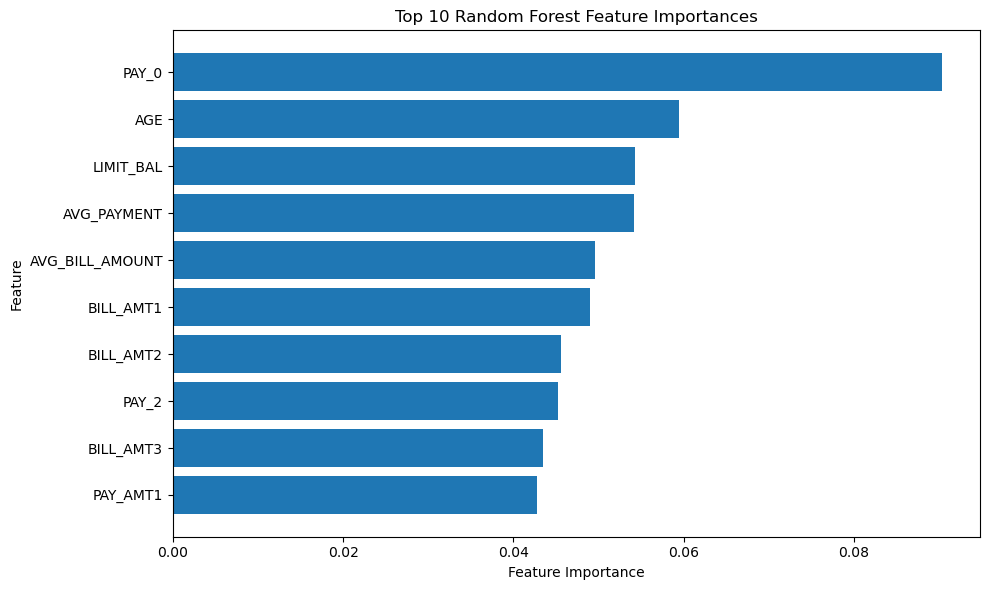

In [64]:
# Create the feature-importance chart

import matplotlib.pyplot as plt

top_10_features = importance_df.head(10).copy()

# Remove preprocessing prefixes for cleaner labels
top_10_features["Feature"] = (
    top_10_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"][::-1],
    top_10_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

## 9. Fairness and Responsible Modelling

In [65]:
# Check performance by SEX
# Evaluate the ordinary Random Forest at its original 0.50 threshold separately for each group

sex_fairness_results = []

for group in sorted(X_test["SEX"].unique()):
    
    group_mask = X_test["SEX"] == group
    
    y_true_group = y_test[group_mask]
    y_pred_group = rf_pred[group_mask]
    
    sex_fairness_results.append({
        "SEX": group,
        "Customers": len(y_true_group),
        "Accuracy": accuracy_score(
            y_true_group,
            y_pred_group
        ),
        "Precision": precision_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        )
    })

sex_fairness_df = pd.DataFrame(sex_fairness_results)

sex_fairness_df.round(4)

,SEX,Customers,Accuracy,Precision,Recall,F1 Score
0,1,2402,0.7989,0.6204,0.3583,0.4542
1,2,3598,0.8218,0.6398,0.3734,0.4716


### Check performance across age groups

Since AGE appeared as the second-highest Random Forest feature importance, age is especially worth examining.

We already created AGE_GROUP during EDA, but it isn't in X_test. Construct the groups directly from X_test["AGE"].

In [66]:
age_test_groups = pd.cut(
    X_test["AGE"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["21–30", "31–40", "41–50", "51–60", "61+"],
    include_lowest=True
)

age_fairness_results = []

for group in age_test_groups.cat.categories:
    
    group_mask = age_test_groups == group
    
    y_true_group = y_test[group_mask]
    y_pred_group = rf_pred[group_mask]
    
    age_fairness_results.append({
        "Age Group": group,
        "Customers": len(y_true_group),
        "Defaults": int(y_true_group.sum()),
        "Accuracy": accuracy_score(
            y_true_group,
            y_pred_group
        ),
        "Precision": precision_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        )
    })

age_fairness_df = pd.DataFrame(age_fairness_results)

age_fairness_df.round(4)

,Age Group,Customers,Defaults,Accuracy,Precision,Recall,F1 Score
0,21–30,2181,479,0.8138,0.6189,0.3967,0.4835
1,31–40,2105,441,0.8147,0.6016,0.3424,0.4364
2,41–50,1243,292,0.8134,0.7027,0.3562,0.4727
3,51–60,413,101,0.7942,0.6481,0.3465,0.4516
4,61+,58,14,0.8103,0.6364,0.5000,0.5600


## 10. Validation and Threshold Selection

The training data was further divided into training and validation subsets.
The validation set was used to compare classification thresholds before the
selected configuration was evaluated on the test set.

In [67]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_train_final.shape)
print("Validation subset:", X_val.shape)

print("\nTraining target distribution:")
print(y_train_final.value_counts(normalize=True).round(4))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).round(4))

Training subset: (19200, 25)
Validation subset: (4800, 25)

Training target distribution:
DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Validation target distribution:
DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [68]:
# Retrain Random Forest on the training subset
# Start with the ordinary Random Forest because it was the main model before threshold tuning.

# Create a fresh pipeline:
rf_validation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [69]:
# Train the validation model
rf_validation_model.fit(
    X_train_final,
    y_train_final
)

# Get validation probabilities
rf_val_prob = rf_validation_model.predict_proba(X_val)[:, 1]

# Compare classification thresholds on validation data
threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:

    val_pred = (rf_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred),
        "Recall": recall_score(y_val, val_pred),
        "F1 Score": f1_score(y_val, val_pred)
    })

validation_threshold_df = pd.DataFrame(threshold_results)

validation_threshold_df.round(4)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.7819,0.5064,0.5612,0.5324
1,0.35,0.8015,0.5551,0.5169,0.5353
2,0.40,0.8092,0.5859,0.4689,0.5209
3,0.45,0.8188,0.6330,0.4303,0.5123
4,0.50,0.8192,0.6575,0.3814,0.4827


In [70]:
# Selected threshold based on validation performance
selected_threshold = 0.35

# Refit Random Forest using the full training dataset
final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

final_rf_model.fit(X_train, y_train)

# Generate probabilities for the test set
final_rf_prob = final_rf_model.predict_proba(X_test)[:, 1]

# Apply the validation-selected threshold
final_rf_pred = (
    final_rf_prob >= selected_threshold
).astype(int)

In [71]:
# Calculate the final confusion matrix:

final_cm = confusion_matrix(
    y_test,
    final_rf_pred
)

final_cm

array([[4085,  588],
       [ 649,  678]])

In [72]:
# And the final metrics:

final_accuracy = accuracy_score(
    y_test,
    final_rf_pred
)

final_precision = precision_score(
    y_test,
    final_rf_pred
)

final_recall = recall_score(
    y_test,
    final_rf_pred
)

final_f1 = f1_score(
    y_test,
    final_rf_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    final_rf_prob
)

print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1 Score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")

Accuracy:  0.7938
Precision: 0.5355
Recall:    0.5109
F1 Score:  0.5229
ROC-AUC:   0.7576


In [73]:
print(
    classification_report(
        y_test,
        final_rf_pred,
        target_names=["No Default", "Default"]
    )
)

              precision    recall  f1-score   support

  No Default       0.86      0.87      0.87      4673
     Default       0.54      0.51      0.52      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.69      0.70      6000
weighted avg       0.79      0.79      0.79      6000



## 11. Evaluation Visuals

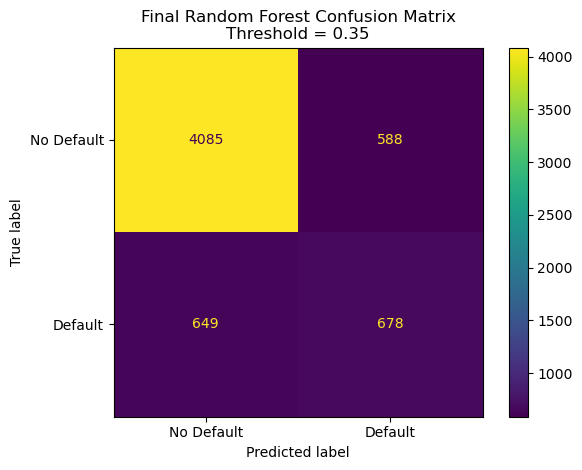

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Default", "Default"]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Final Random Forest Confusion Matrix\n"
    "Threshold = 0.35"
)

plt.tight_layout()
plt.show()

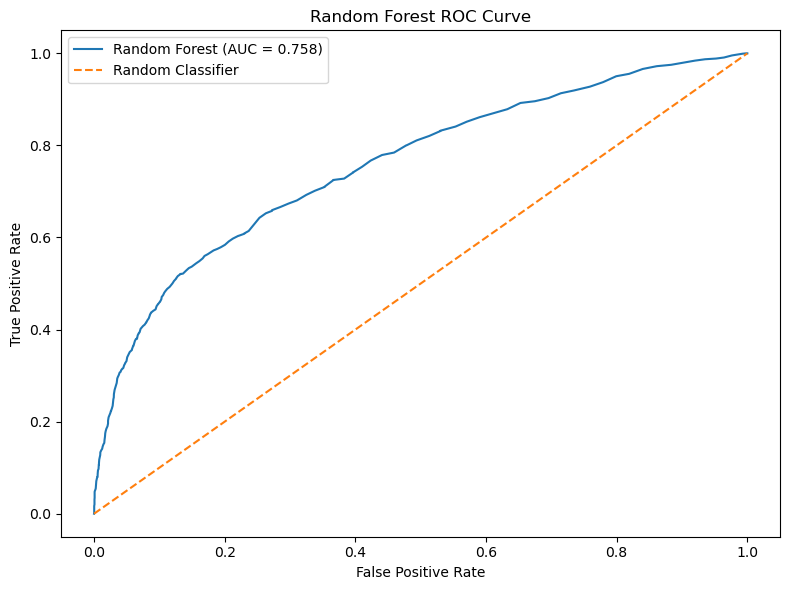

In [75]:
# Create the ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    final_rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {final_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

## 12. Final Model Evaluation

A Random Forest classifier was selected for final evaluation after comparing
Logistic Regression, Random Forest, and class-weighted Random Forest models.

Because the dataset is moderately imbalanced, model performance was evaluated
using precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

A validation set was used to examine classification thresholds. A threshold of
0.35 was selected because it produced the highest F1-score among the tested
thresholds while substantially improving recall for the default class compared
with the standard 0.50 threshold.

The final Random Forest model was retrained on the full training dataset and
evaluated on the test set excluded from model training.

### Final Test Performance

- Accuracy: 79.38%
- Precision (Default): 53.55%
- Recall (Default): 51.09%
- F1-score (Default): 52.29%
- ROC-AUC: 75.76%

At the selected 0.35 threshold, the model correctly identified 678 of the
1,327 customers who defaulted, corresponding to a recall of 51.09%.

The confusion matrix contained:

- True Negatives: 4,085
- False Positives: 588
- False Negatives: 649
- True Positives: 678

Lowering the classification threshold improved the model's ability to identify
customers who defaulted, but this came at the cost of additional false-positive
predictions.

The ROC-AUC of 0.7576 indicates that the model has useful discriminatory ability,
although substantial prediction error remains. The model should therefore be
treated as an educational predictive modelling exercise rather than a
production-ready credit decision system.

## 13. Business Insights and Model Limitations

### Key Insights

1. **Recent repayment behaviour was strongly associated with default risk.**
   `PAY_0`, representing the most recent repayment-status variable, was the
   highest-ranked feature in the Random Forest feature-importance analysis.
   Earlier exploratory analysis also showed substantially higher default rates
   among several delinquent repayment-status groups.

2. **Credit limit differed between customers who defaulted and those who did not.**
   Customers who defaulted had a median credit limit of 90,000 compared with
   150,000 among customers who did not default. This represents an association
   in the dataset and should not be interpreted as evidence that lower credit
   limits cause default.

3. **Payment behaviour provided useful predictive information.**
   Customers who defaulted had a lower median average payment across the six
   payment periods than customers who did not default. `AVG_PAYMENT`, an
   engineered feature, was also among the most important Random Forest features.

4. **Threshold selection materially affected default detection.**
   At the standard 0.50 threshold, the Random Forest detected approximately
   37% of actual defaults. A threshold of 0.35 was selected using validation
   data and produced 51.09% recall on the final test set.

5. **Improved default detection involved a trade-off.**
   At the final 0.35 threshold, the model correctly identified 678 actual
   defaults but generated 588 false-positive predictions. Threshold selection
   should therefore depend on the relative business costs of false negatives
   and false positives.

### Fairness and Responsible Modelling

Model performance was examined across the demographic variables SEX and AGE.

Recall across the two SEX groups was relatively similar in the test sample,
at approximately 35.83% and 37.34% when the Random Forest was evaluated at
the original 0.50 threshold.

Performance also varied across age groups. However, some groups contained
substantially fewer observations. In particular, the 61+ test group contained
only 58 customers and 14 actual defaults, making its performance estimates
less stable.

These subgroup checks are exploratory and are not sufficient to establish
that the model is fair. A production credit-risk system would require more
extensive fairness testing, consideration of sensitive attributes and proxy
variables, appropriate governance, and assessment within the relevant legal
and regulatory context.

### Limitations

- The analysis identifies statistical associations and predictive patterns,
  not causal relationships.
- The model still missed 649 of the 1,327 actual defaults in the test set.
- Feature importance indicates how much features contributed to Random Forest
  splits but does not show causal effects or the direction of those effects.
- Engineered average payment and bill features contain information derived
  from variables already present in the dataset, creating some redundancy.
- Demographic variables require particular care in credit-risk modelling.
- Results from this historical dataset may not generalise to different
  populations, time periods, economic conditions, or real-world lending
  environments.
- The project is an educational portfolio exercise and should not be used
  directly for real lending decisions.